# Error Correction Methods in Classification & Regression
### A hands-on implementation notebook

This notebook implements every technique from the companion slide deck, in the same order:

1. Regression error metrics (MAE, MSE, RMSE, R²)
2. Classification error metrics (confusion matrix, accuracy, precision, recall, F1)
3. Boosting (AdaBoost)
4. Gradient Boosting (residual fitting)
5. Bagging / Random Forest
6. Regularization (Lasso L1 / Ridge L2)
7. Error-Correcting Output Codes (ECOC)
8. Cross-validation
9. Final comparison summary

Each section includes: the formula, a small worked-by-hand example, and a full scikit-learn implementation on synthetic data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import make_regression, make_classification
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingClassifier, RandomForestClassifier, RandomForestRegressor,
)
from sklearn.multiclass import OutputCodeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
print("Libraries loaded.")

Libraries loaded.


## 1. Regression Error Metrics

**Formulas**

$$MAE = \frac{1}{n}\sum_i |y_i - \hat{y}_i| \qquad MSE = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2 \qquad RMSE = \sqrt{MSE}$$

**Worked example** (from the slides): Actual sales = [100, 150, 200], Predicted = [110, 140, 220]

In [2]:
actual = np.array([100, 150, 200])
predicted = np.array([110, 140, 220])

errors = actual - predicted
mae_manual = np.mean(np.abs(errors))
mse_manual = np.mean(errors ** 2)
rmse_manual = np.sqrt(mse_manual)

print("Errors:", errors)
print(f"MAE  = {mae_manual:.2f}")
print(f"MSE  = {mse_manual:.2f}")
print(f"RMSE = {rmse_manual:.2f}")

# Cross-check with sklearn
print("\nsklearn check ->",
      "MAE:", mean_absolute_error(actual, predicted),
      "| MSE:", mean_squared_error(actual, predicted))

Errors: [-10  10 -20]
MAE  = 13.33
MSE  = 200.00
RMSE = 14.14

sklearn check -> MAE: 13.333333333333334 | MSE: 200.0


MAE  = 11.04
MSE  = 209.86
RMSE = 14.49
R²   = 0.982


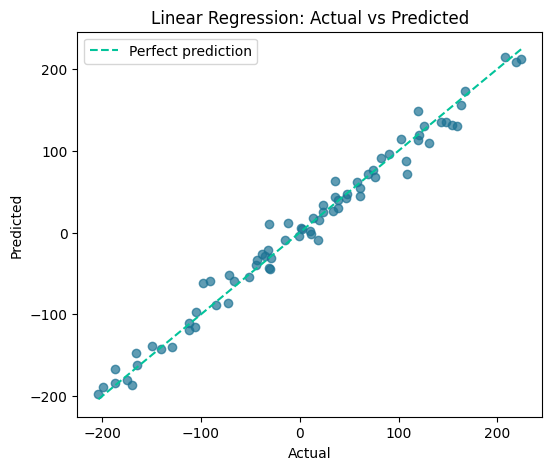

In [3]:
# Full implementation on a synthetic regression dataset (house price style)
X, y = make_regression(n_samples=300, n_features=5, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_reg = LinearRegression().fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.7, color="#1C7293")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="#02C39A", label="Perfect prediction")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Linear Regression: Actual vs Predicted")
ax.legend()
plt.show()

## 2. Classification Error Metrics

**Formulas**

$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN} \qquad Precision = \frac{TP}{TP+FP} \qquad Recall = \frac{TP}{TP+FN}$$

$$F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

**Example**: tumor-detection style problem (42 TP, 5 FN, 3 FP, 50 TN — as in the slides).

In [4]:
TP, FN, FP, TN = 42, 5, 3, 50

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy  = {accuracy:.3f}")
print(f"Precision = {precision:.3f}")
print(f"Recall    = {recall:.3f}")
print(f"F1-score  = {f1:.3f}")

Accuracy  = 0.920
Precision = 0.933
Recall    = 0.894
F1-score  = 0.913


Confusion matrix:
 [[60  2]
 [23 40]]
Accuracy  = 0.800
Precision = 0.952
Recall    = 0.635
F1-score  = 0.762


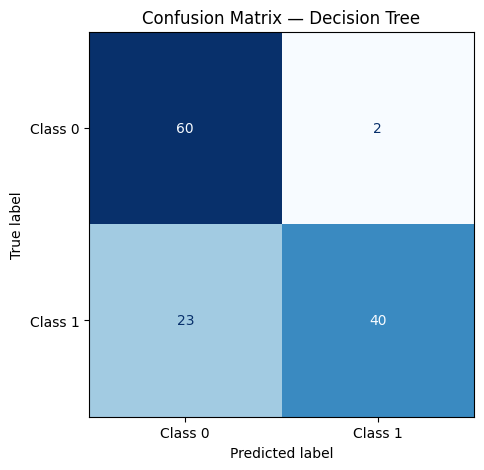

In [5]:
# Full implementation on a synthetic binary classification dataset
Xc, yc = make_classification(n_samples=500, n_features=10, n_informative=6,
                              weights=[0.6, 0.4], random_state=42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

cm = confusion_matrix(yc_test, yc_pred)
print("Confusion matrix:\n", cm)
print(f"Accuracy  = {accuracy_score(yc_test, yc_pred):.3f}")
print(f"Precision = {precision_score(yc_test, yc_pred):.3f}")
print(f"Recall    = {recall_score(yc_test, yc_pred):.3f}")
print(f"F1-score  = {f1_score(yc_test, yc_pred):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Decision Tree")
plt.show()

## 3. Boosting — AdaBoost

**Formulas**

$$\alpha_t = \frac{1}{2}\ln\left(\frac{1-err_t}{err_t}\right) \qquad w_i \leftarrow w_i \cdot e^{\alpha_t \cdot \mathbb{1}[y_i \neq \hat{y}_i]}$$

$$F(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$$

Each weak learner is trained on reweighted data that emphasizes previously misclassified points; the final prediction is a weighted vote.

Single decision stump accuracy : 0.712
AdaBoost (100 stumps) accuracy  : 0.776


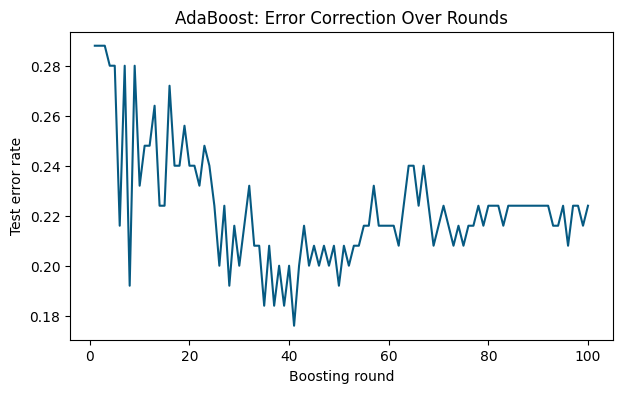

In [6]:
# Compare a single weak learner (stump) vs AdaBoost ensemble on the same data
stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(Xc_train, yc_train)
stump_acc = accuracy_score(yc_test, stump.predict(Xc_test))

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, learning_rate=1.0, random_state=42
).fit(Xc_train, yc_train)
ada_acc = accuracy_score(yc_test, ada.predict(Xc_test))

print(f"Single decision stump accuracy : {stump_acc:.3f}")
print(f"AdaBoost (100 stumps) accuracy  : {ada_acc:.3f}")

# Error rate as more weak learners are added
errors_by_round = [
    1 - accuracy_score(yc_test, pred)
    for pred in ada.staged_predict(Xc_test)
]
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(errors_by_round) + 1), errors_by_round, color="#065A82")
plt.xlabel("Boosting round")
plt.ylabel("Test error rate")
plt.title("AdaBoost: Error Correction Over Rounds")
plt.show()

## 4. Gradient Boosting — Fit the Residuals

**Formula**

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x), \quad \text{where } h_m(x) \text{ fits residual } r_i = y_i - F_{m-1}(x_i)$$

**Worked example**: reproduce the staged residual shrinkage table from the slides.

In [7]:
# Simple manual illustration of residual fitting on 1 data point set
y_true_house = 350000
stage_preds = [300000]  # start at average
residual = y_true_house - stage_preds[-1]
learning_rate = 0.7
for _ in range(3):
    # a weak learner "learns" a fraction of the residual (idealized)
    step = residual * learning_rate
    stage_preds.append(stage_preds[-1] + step)
    residual = y_true_house - stage_preds[-1]

for i, p in enumerate(stage_preds):
    label = "Start (avg)" if i == 0 else f"+ Model {i}"
    print(f"{label:12s} prediction = ${p:,.0f}   residual = ${y_true_house - p:,.0f}")

Start (avg)  prediction = $300,000   residual = $50,000
+ Model 1    prediction = $335,000   residual = $15,000
+ Model 2    prediction = $345,500   residual = $4,500
+ Model 3    prediction = $348,650   residual = $1,350


Gradient Boosting  -> MAE: 21.68, RMSE: 28.27
Plain Linear Reg.  -> MAE: 11.04, RMSE: 14.49


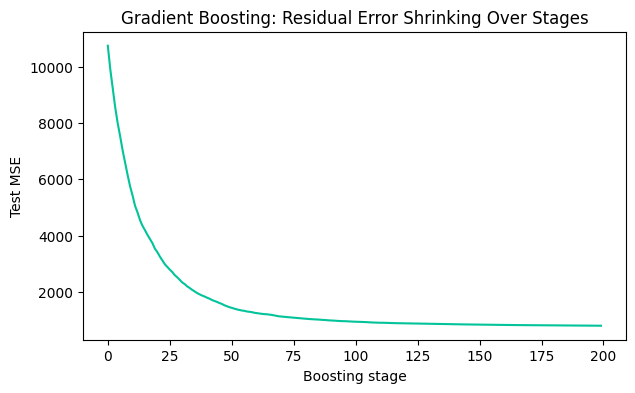

In [8]:
# Full implementation: Gradient Boosting Regressor on synthetic data
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                 max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print(f"Gradient Boosting  -> MAE: {mean_absolute_error(y_test, y_pred_gbr):.2f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gbr)):.2f}")
print(f"Plain Linear Reg.  -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Track how training error shrinks stage by stage (the "residual correction" in action)
test_mse_by_stage = [
    mean_squared_error(y_test, pred) for pred in gbr.staged_predict(X_test)
]
plt.figure(figsize=(7, 4))
plt.plot(test_mse_by_stage, color="#02C39A")
plt.xlabel("Boosting stage")
plt.ylabel("Test MSE")
plt.title("Gradient Boosting: Residual Error Shrinking Over Stages")
plt.show()

## 5. Bagging — Average Away the Noise

Bagging trains many models in **parallel** on bootstrap-sampled data, then averages (regression) or votes (classification), reducing variance.

Single Decision Tree accuracy : 0.832
Bagging (100 trees) accuracy  : 0.872
Random Forest accuracy        : 0.880


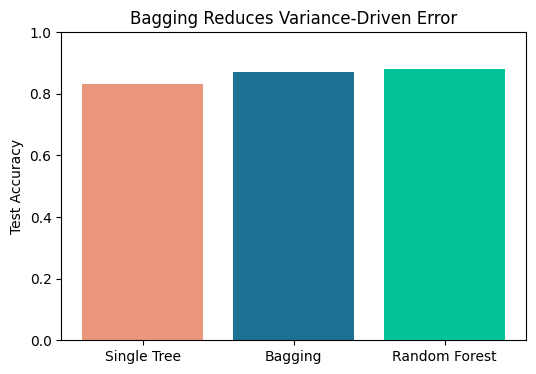

In [9]:
# Single tree vs Bagging vs Random Forest on the classification data
single_tree = DecisionTreeClassifier(random_state=42).fit(Xc_train, yc_train)
single_tree_acc = accuracy_score(yc_test, single_tree.predict(Xc_test))

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42
).fit(Xc_train, yc_train)
bagging_acc = accuracy_score(yc_test, bagging.predict(Xc_test))

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xc_train, yc_train)
rf_acc = accuracy_score(yc_test, rf.predict(Xc_test))

print(f"Single Decision Tree accuracy : {single_tree_acc:.3f}")
print(f"Bagging (100 trees) accuracy  : {bagging_acc:.3f}")
print(f"Random Forest accuracy        : {rf_acc:.3f}")

plt.figure(figsize=(6, 4))
plt.bar(["Single Tree", "Bagging", "Random Forest"],
        [single_tree_acc, bagging_acc, rf_acc],
        color=["#E9967A", "#1C7293", "#02C39A"])
plt.ylabel("Test Accuracy")
plt.title("Bagging Reduces Variance-Driven Error")
plt.ylim(0, 1)
plt.show()

## 6. Regularization — Lasso (L1) & Ridge (L2)

**Formulas**

$$\text{Lasso: } \; Loss = \sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_j |w_j| \qquad \text{Ridge: } \; Loss = \sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_j w_j^2$$

Lasso can zero out coefficients (automatic feature selection); Ridge shrinks all coefficients smoothly.

Plain Linear   -> RMSE: 12.24   | non-zero coefs: 20/20
Lasso (L1)     -> RMSE: 12.34   | non-zero coefs: 9/20
Ridge (L2)     -> RMSE: 12.31   | non-zero coefs: 20/20


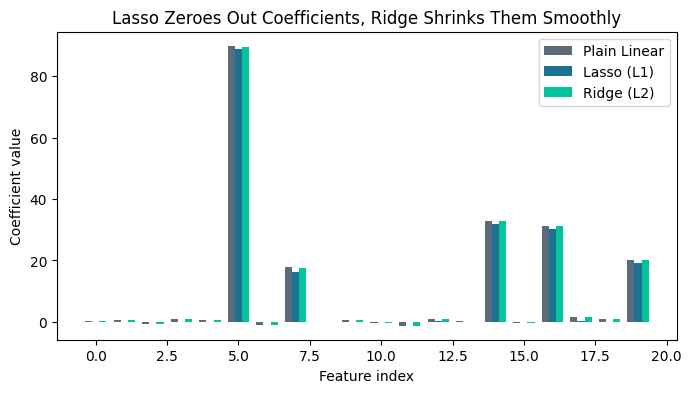

In [10]:
# Build a regression dataset with several irrelevant/noisy features
X_reg, y_reg = make_regression(n_samples=300, n_features=20, n_informative=5,
                                noise=10, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

plain = LinearRegression().fit(Xr_train, yr_train)
lasso = Lasso(alpha=1.0, random_state=42).fit(Xr_train, yr_train)
ridge = Ridge(alpha=1.0, random_state=42).fit(Xr_train, yr_train)

for name, model in [("Plain Linear", plain), ("Lasso (L1)", lasso), ("Ridge (L2)", ridge)]:
    pred = model.predict(Xr_test)
    print(f"{name:14s} -> RMSE: {np.sqrt(mean_squared_error(yr_test, pred)):.2f}   "
          f"| non-zero coefs: {np.sum(np.abs(model.coef_) > 1e-6)}/{len(model.coef_)}")

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
idx = np.arange(len(plain.coef_))
ax.bar(idx - width, plain.coef_, width, label="Plain Linear", color="#5B6B79")
ax.bar(idx, lasso.coef_, width, label="Lasso (L1)", color="#1C7293")
ax.bar(idx + width, ridge.coef_, width, label="Ridge (L2)", color="#02C39A")
ax.set_xlabel("Feature index")
ax.set_ylabel("Coefficient value")
ax.set_title("Lasso Zeroes Out Coefficients, Ridge Shrinks Them Smoothly")
ax.legend()
plt.show()

## 7. Error-Correcting Output Codes (ECOC)

**Formula (decoding rule)**

$$class^{*} = \arg\min_k \sum_i |output_i - codeword_{k,i}|$$

ECOC splits a multi-class problem into several binary problems using a codeword matrix; redundancy lets it correct individual classifier mistakes.

In [11]:
# Multi-class dataset (4 classes, like Cat/Dog/Bird/Fish in the slides)
Xm, ym = make_classification(n_samples=600, n_features=12, n_informative=8,
                              n_classes=4, n_clusters_per_class=1, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.25, random_state=42)

# Baseline: one-vs-rest style default multiclass handling
plain_svc = LinearSVC(random_state=42, max_iter=5000, dual=True).fit(Xm_train, ym_train)
plain_acc = accuracy_score(ym_test, plain_svc.predict(Xm_test))

# ECOC with a generous code size for redundancy / error correction
ecoc = OutputCodeClassifier(
    estimator=LinearSVC(random_state=42, max_iter=5000, dual=True),
    code_size=15, random_state=42
).fit(Xm_train, ym_train)
ecoc_acc = accuracy_score(ym_test, ecoc.predict(Xm_test))

print(f"Plain multi-class LinearSVC accuracy : {plain_acc:.3f}")
print(f"ECOC-wrapped LinearSVC accuracy      : {ecoc_acc:.3f}")
print(f"ECOC codebook shape (classes x bits) : {ecoc.code_book_.shape}")
print("\nSample codewords (rows = classes):\n", ecoc.code_book_[:4].astype(int))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Plain multi-class LinearSVC accuracy : 0.747
ECOC-wrapped LinearSVC accuracy      : 0.733
ECOC codebook shape (classes x bits) : (4, 60)

Sample codewords (rows = classes):
 [[-1  1  1  1 -1 -1 -1  1  1  1 -1  1  1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1
  -1  1 -1  1  1 -1  1 -1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1  1 -1  1 -1  1
   1 -1  1  1  1  1  1  1 -1 -1 -1 -1]
 [-1 -1  1 -1 -1  1 -1  1 -1  1  1 -1 -1  1  1  1  1 -1 -1 -1  1  1 -1 -1
  -1 -1  1  1  1 -1 -1  1  1  1  1 -1  1 -1 -1 -1 -1  1 -1  1  1 -1 -1  1
  -1 -1 -1 -1  1  1  1  1  1 -1  1  1]
 [ 1  1 -1 -1 -1 -1  1  1 -1  1 -1 -1 -1 -1  1 -1  1  1 -1  1  1 -1 -1 -1
  -1 -1  1  1 -1 -1  1 -1 -1 -1  1 -1  1  1 -1  1 -1  1  1  1 -1  1 -1 -1
  -1  1  1 -1  1 -1  1 -1  1 -1  1 -1]
 [-1 -1  1  1 -1  1  1  1  1 -1 -1  1  1  1 -1 -1  1  1  1  1  1 -1 -1  1
   1 -1 -1  1 -1 -1  1  1  1 -1  1 -1 -1  1  1  1  1  1 -1 -1 -1 -1  1 -1
   1  1  1  1  1 -1 -1  1 -1 -1  1 -1]]


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 8. Cross-Validation — Trustworthy Error Estimates

K-fold cross-validation rotates the test fold so every point is evaluated exactly once, revealing whether an error estimate is stable or overfit to one split.

Fold 1: RMSE = 27.59


Fold 2: RMSE = 30.11


Fold 3: RMSE = 26.06


Fold 4: RMSE = 29.13


Fold 5: RMSE = 33.81

Mean RMSE across folds: 29.34  (+/- 2.62)


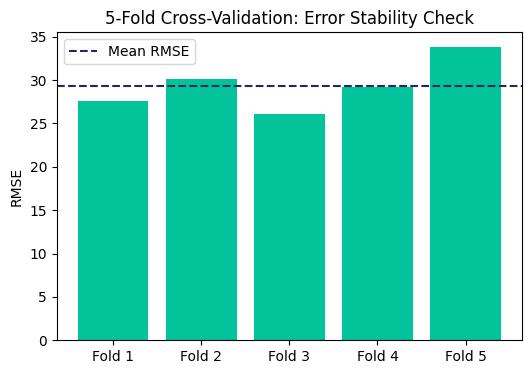

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_for_cv = RandomForestRegressor(n_estimators=200, random_state=42)

fold_rmse = []
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    model_for_cv.fit(X[train_idx], y[train_idx])
    pred = model_for_cv.predict(X[test_idx])
    rmse_fold = np.sqrt(mean_squared_error(y[test_idx], pred))
    fold_rmse.append(rmse_fold)
    print(f"Fold {fold_i}: RMSE = {rmse_fold:.2f}")

print(f"\nMean RMSE across folds: {np.mean(fold_rmse):.2f}  (+/- {np.std(fold_rmse):.2f})")

plt.figure(figsize=(6, 4))
plt.bar([f"Fold {i}" for i in range(1, 6)], fold_rmse, color="#02C39A")
plt.axhline(np.mean(fold_rmse), color="#21295C", linestyle="--", label="Mean RMSE")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation: Error Stability Check")
plt.legend()
plt.show()

## 9. Summary — Choosing the Right Correction Method

| Method | Best For | Corrects | Example Use |
|---|---|---|---|
| Boosting (AdaBoost) | Both | Bias (underfitting) | Fraud detection |
| Gradient Boosting | Regression & classification | Residual error | Price forecasting |
| Bagging / Random Forest | Both | Variance (overfitting) | Churn prediction |
| Regularization (L1/L2) | Both | Overfitting / noise | High-dimensional data |
| ECOC | Classification | Individual model mistakes | Multi-class image tagging |
| Cross-validation | Both | Unreliable error estimates | Model selection |

**Key takeaway:** no single method fixes every kind of error — match the technique to whether the problem is bias, variance, noisy/irrelevant features, or class imbalance.